# Aprendizaje Profundo: Aplicación de NLP y Embeddings.

<!-- ===================================================== -->
<!-- 📚 ÍNDICE -->
<!-- ===================================================== -->

<h2 id="toc">📚 Índice interactivo</h2>

<ul>
  <li><a href="#introduccion">1. Introducción</a></li>
  <li>
    <a href="#exploracion">2. Análisis Exploratorio</a>
    <ul>
      <li><a href="#estadisticageneral">2.1. Análisis Estadístico General</a></li>
      <li><a href="#estadisticapalabras">2.2. Análisis Estadístico de las Palabras</a></li>
    </ul>
  </li>
  <li>
    <a href="#preprocesamiento">3. Preprocesamiento del texto</a>
    <ul>
      <li><a href="#TD-IDF">3.1. Representación vectorial con TF-IDF</a></li>
      <li><a href="#EMBEDDING">3.2. Representación con embeddings</a></li>
      <li><a href="#interpretacion">3.3. Interpretación y conclusiones</a></li>
    </ul>
  </li>
  <li>
    <a href="#modelos">4. Modelos de Clasificación de Sentimientos</a>
    <ul>
      <li><a href="#modelosbasicos">4.1. Modelos básicos de clasificación</a></li>
      <li><a href="#palabras-importantes">4.2. Palabras más importantes por sentimiento</a></li>
      <li><a href="#wordcloud-sentimiento">4.3. WordCloud por sentimiento</a></li>
    </ul>
  </li>
</ul>

<style>
/* ======= Estilo del índice ======= */
#toc {
  color: #1f77b4;
  margin-bottom: 10px;
}
ul {
  list-style-type: none;
  padding-left: 1em;
}
ul li {
  margin: 4px 0;
}
ul li a {
  text-decoration: none;
  color: #0072bb;
}
ul li a:hover {
  text-decoration: underline;
  color: #005999;
}

/* ======= Anclas invisibles ======= */
.anchor {
  display: block;
  position: relative;
  top: -80px; /* ajustar según la altura de tu encabezado fijo */
  visibility: hidden;
}

/* ======= Desplazamiento suave ======= */
html {
  scroll-behavior: smooth;
}
</style>


<div id="introduccion" class="anchor"></div>
<h2>1. Introducción</h2>

#### Contexto general

El análisis de sentimientos es una de las tareas más representativas del **Procesamiento de Lenguaje Natural (NLP)**. Consiste en determinar si un texto expresa una opinión **positiva o negativa**, aplicando métodos de representación semántica y modelos de clasificación supervisados.

Analizaremos el problema de la **clasificación binaria de sentimientos** a partir de reseñas de películas del portal IMDB.  
El conjunto de datos seleccionado permite comparar diferentes estrategias de preprocesamiento y modelado, desde enfoques tradicionales basados en TF-IDF hasta representaciones distribuidas (*word embeddings*) y modelos neuronales.


#### Dataset utilizado

* ***Título***: IMDB Dataset of 50K Movie Reviews
* ***Autor***: Lakshmi N Pathi (Kaggle)
* ***Fuente***: [dataset de reviews de IMDB](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/code)
* **Tipo de problema:** Clasificación binaria (positivo / negativo)

| Columna     | Tipo       | Descripción                             |
| ----------- | ---------- | --------------------------------------- |
| `review`    | texto      | Texto completo de la reseña de película |
| `sentiment` | categórica | “positive” o “negative”                 |

#### Características generales

- Tamaño equilibrado: 25.000 positivas y 25.000 negativas.
- Ideal para probar modelos de NLP (procesamiento de lenguaje natural) como:
    - Bag of Words, TF-IDF.
    - Word embeddings (Word2Vec, GloVe).
- Redes neuronales (LSTM, Transformers).
- Dataset limpio, sin etiquetas neutras ni puntuaciones numéricas.


### Referencias
> Maas, A. L., Daly, R. E., Pham, P. T., Huang, D., Ng, A. Y., & Potts, C. (2011).  
> *Learning Word Vectors for Sentiment Analysis.* Proceedings of the 49th Annual Meeting of the Association for Computational Linguistics (ACL-HLT).  
> [https://aclanthology.org/P11-1015.pdf](https://aclanthology.org/P11-1015.pdf)


<div id="exploracion" class="anchor"></div>
<h2>2. Análisis Exploratorio</h2>

Antes de comenzar con el análisis, debemos importar todas las librerías que utilizaremos.

In [2]:
# =====================================
# 🔧 Control de entorno y reproducibilidad
# =====================================

import sys
import random
import numpy as np
import torch

# Versión de Python
print(f"Versión de Python: {sys.version.split()[0]}")

# Fijar semillas aleatorias
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Si hay GPU disponible (por ejemplo, en Colab)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Semilla global fijada en: {SEED}")


Versión de Python: 3.9.23
Semilla global fijada en: 42


Fijamos una **semilla global (SEED=42)** para `random`, `numpy` y `torch`, y desactivamos heurísticas no deterministas de cuDNN.  
Esto permite que los resultados (splits, inicializaciones, métricas) sean **comparables** entre corridas y entre integrantes del grupo.  
Aun con SEED, algunas operaciones GPU pueden variar levemente según drivers/versión, pero el seteo actual minimiza esas diferencias.


In [3]:
# =====================================
# Importación de librerías
# =====================================

# Utilidades generales
import re
import pandas as pd
from collections import Counter
import os
import zipfile
import shutil

# Kaggle (descarga de datasets)
import kagglehub

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

# Procesamiento de Lenguaje Natural
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier


In [4]:
# =====================================
# Información de entorno
# =====================================
import session_info
session_info.show(html=False)

-----
kagglehub           0.3.8
matplotlib          3.9.4
nltk                3.9.1
numpy               1.26.4
pandas              2.3.0
seaborn             0.13.2
session_info        v1.0.1
sklearn             1.6.1
torch               2.5.1
wordcloud           1.9.4
-----
IPython             8.18.1
jupyter_client      8.6.3
jupyter_core        5.8.1
jupyterlab          4.4.5
notebook            7.4.4
-----
Python 3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12) [GCC 13.3.0]
Linux-6.5.0-27-generic-x86_64-with-glibc2.35
-----
Session information updated at 2025-10-09 12:27


Primero, descargamos el dataset desde `kaggle` a una carpeta de archivos temporales:

In [5]:
# ====================================
# 1️. Descargar el dataset desde Kaggle
# ====================================

# Usamos la función 'dataset_download' del módulo 'kagglehub'
# para descargar el dataset "IMDB Dataset of 50K Movie Reviews" de Kaggle
# La variable 'path' almacenará la ruta local donde se guardó el archivo
dataset_path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

# Imprimimos la ruta del archivo descargado
# Esto es útil para saber dónde se encuentra el dataset en tu sistema
print("Carpeta con los archivos del dataset (caché de Kaggle):", dataset_path)

Carpeta con los archivos del dataset (caché de Kaggle): /home/dalma/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1


Generamos una carpeta local. Luego movemos el archivo de la carpeta temporal a la local. Finalmente creamos un dataframe:

In [6]:
# ========================================================
# 2️. Buscar el archivo CSV dentro de la carpeta descargada
# ========================================================
csv_file = None
for f in os.listdir(dataset_path):
    if f.endswith(".csv"):  # Buscamos archivos que terminen con '.csv'
        csv_file = os.path.join(dataset_path, f)
        break

# Si no se encuentra el archivo, lanzamos un error
if csv_file is None:
    raise FileNotFoundError("No se encontró el archivo CSV dentro de la carpeta descargada.")

# Determinamos el archivo encontrado
print("Archivo CSV encontrado:", csv_file)

# =====================================
# 3. Crear carpeta local en el notebook
# =====================================
# Creamos una carpeta llamada 'imdb_dataset' en el directorio donde está el notebook
local_folder = "imdb_dataset"
os.makedirs(local_folder, exist_ok=True)  # exist_ok=True evita error si ya existe

# ============================================================
# 4️. Copiar el CSV desde la caché de Kaggle a la carpeta local
# ============================================================
# Esto asegura que trabajemos directamente desde nuestro directorio del notebook
local_csv_file = os.path.join(local_folder, os.path.basename(csv_file))
shutil.copy(csv_file, local_csv_file)
print(f"Archivo CSV copiado a la carpeta local: {local_csv_file}")

# ==========================================
# 5️. Cargar el CSV en un DataFrame de pandas
# ==========================================
# Ahora podemos trabajar con el DataFrame directamente desde la carpeta local
df = pd.read_csv(local_csv_file)


Archivo CSV encontrado: /home/dalma/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1/IMDB Dataset.csv
Archivo CSV copiado a la carpeta local: imdb_dataset/IMDB Dataset.csv


Veamos ahora una exploración básica del DataFrame, donde buscamos:

* Ver las primeras filas (`df.head()`)
* Información general (`df.info()`) y tipos de datos
* Conteo de etiquetas (`df['sentiment'].value_counts()`)
* Revisar si hay valores nulos (`df.isnull().sum()`)

In [7]:
# Informacion General
print("\nInformación general del DataFrame:")
print(df.info())


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None


In [8]:
# Primeras filas del DataFrame
print("Primeras 20 filas del DataFrame:")
print(df.head(20))

Primeras 20 filas del DataFrame:
                                               review sentiment
0   One of the other reviewers has mentioned that ...  positive
1   A wonderful little production. <br /><br />The...  positive
2   I thought this was a wonderful way to spend ti...  positive
3   Basically there's a family where a little boy ...  negative
4   Petter Mattei's "Love in the Time of Money" is...  positive
5   Probably my all-time favorite movie, a story o...  positive
6   I sure would like to see a resurrection of a u...  positive
7   This show was an amazing, fresh & innovative i...  negative
8   Encouraged by the positive comments about this...  negative
9   If you like original gut wrenching laughter yo...  positive
10  Phil the Alien is one of those quirky films wh...  negative
11  I saw this movie when I was about 12 when it c...  negative
12  So im not a big fan of Boll's work but then ag...  negative
13  The cast played Shakespeare.<br /><br />Shakes...  negative
14  Thi

In [9]:
# Conteo de etiquetas
print("\nConteo de etiquetas de sentimiento:")
print(df['sentiment'].value_counts())


Conteo de etiquetas de sentimiento:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [10]:
# Valores nulos
print("\nConteo de valores nulos:")
print(df.isnull().sum())


Conteo de valores nulos:
review       0
sentiment    0
dtype: int64


<div id="estadisticageneral" class="anchor"></div>
<h3>2.1. Análisis Estadístico General</h3>

En lo que sigue, realizaremos un análisis exploratorio del dataset:

* Longitud de las reseñas: número de palabras o caracteres.
* Distribución de la longitud separada por sentimiento (`positive` vs. `negative`).
* Identificar las reseñas más largas y más cortas, tanto en palabras como en caracteres, mostrando un extracto de cada una.
* Palabras más frecuentes y `WordCloud` por sentimiento.
* Longitud de las reseñas: número de palabras o caracteres.
* Distribución de la longitud separada por sentimiento (`positive` vs. `negative`).
* Identificar las reseñas más largas y más cortas, tanto en palabras como en caracteres, mostrando un extracto de cada una.
* Palabras más frecuentes y `WordCloud` por sentimiento.

In [11]:
# ===================================
# 1. Calcular longitud de cada reseña
# ===================================

# Número de palabras por reseña
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))

# Número de caracteres por reseña
df['char_count'] = df['review'].apply(lambda x: len(str(x)))

# Mostrar estadísticas básicas sobre longitud de las reseñas
# describe() incluye conteo, media, desviación estándar, valores mínimo y máximo, percentiles
print("Estadísticas básicas de longitud de reseñas (palabras y caracteres):")
print(df[['word_count','char_count']].describe())

Estadísticas básicas de longitud de reseñas (palabras y caracteres):
         word_count    char_count
count  50000.000000  50000.000000
mean     231.156940   1309.431020
std      171.343997    989.728014
min        4.000000     32.000000
25%      126.000000    699.000000
50%      173.000000    970.000000
75%      280.000000   1590.250000
max     2470.000000  13704.000000


Las reseñas muestran una distribución **asimétrica** (cola hacia textos largos). Como tendencia, las **positivas** tienden a ser **ligeramente más largas** que las negativas. **Implicancia:** los modelos basados en bolsa de palabras/TF-IDF reciben más señales en reseñas largas; conviene considerar **recortes máximos** o **normalizaciones** para evitar que outliers dominen.



In [12]:
# =========================================================
# 2. Comparación de longitud media por sentimiento
# =========================================================
mean_lengths = df.groupby('sentiment')[['word_count','char_count']].mean()
print("\nLongitud media de reseñas por sentimiento:")
print(mean_lengths)


Longitud media de reseñas por sentimiento:
           word_count  char_count
sentiment                        
negative    229.46456  1294.06436
positive    232.84932  1324.79768


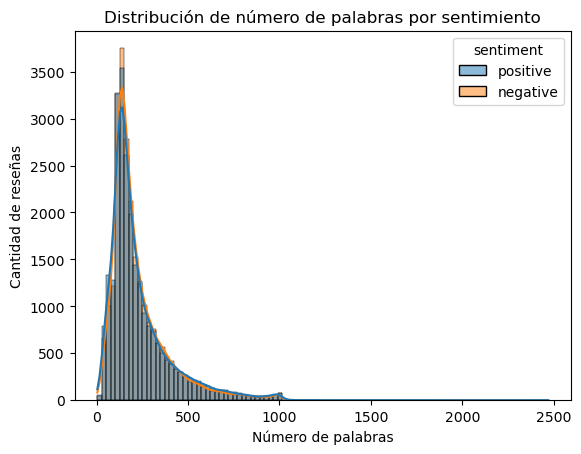

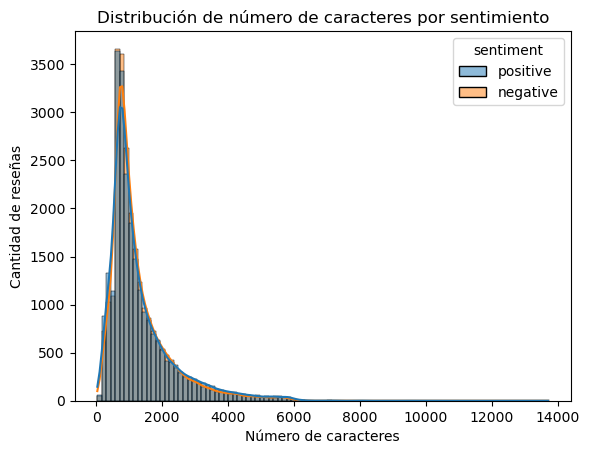

In [13]:
# =========================================================
# 3. Visualizar la distribución de longitud por sentimiento
# =========================================================

# Separamos por 'sentiment' para ver diferencias entre positivas y negativas
sns.histplot(data=df, x='word_count', hue='sentiment', bins=100, kde=True)
plt.title("Distribución de número de palabras por sentimiento")
plt.xlabel("Número de palabras")
plt.ylabel("Cantidad de reseñas")
plt.show()

sns.histplot(data=df, x='char_count', hue='sentiment', bins=100, kde=True)
plt.title("Distribución de número de caracteres por sentimiento")
plt.xlabel("Número de caracteres")
plt.ylabel("Cantidad de reseñas")
plt.show()

Las distribuciones de longitud para ambos sentimientos **se superponen** en gran medida, con una leve **desplazamiento** hacia mayor longitud en positivas.  Por lo tanto, la longitud **no** separa por sí sola las clases; necesitaremos rasgos léxicos/semánticos.


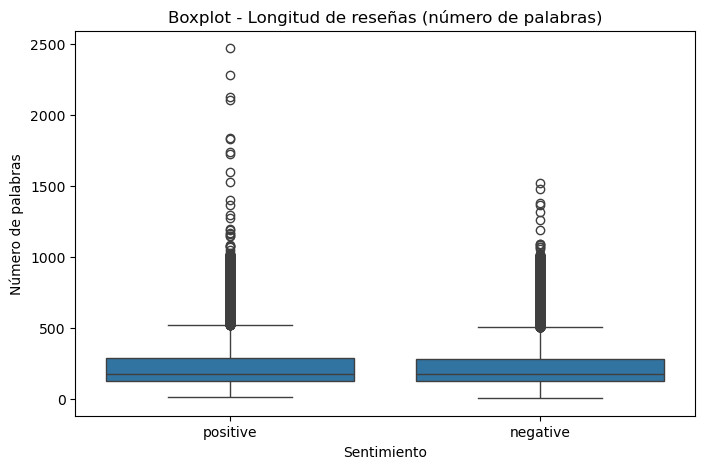

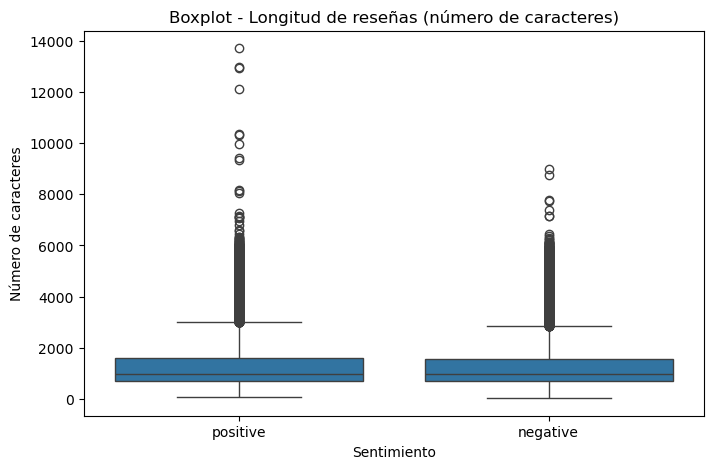

In [14]:
# ============================================
# 4. Boxplots de longitud (comparación visual)
# ============================================
# Boxplot para el conteo de palabras
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='sentiment', y='word_count')
plt.title("Boxplot - Longitud de reseñas (número de palabras)")
plt.xlabel("Sentimiento")
plt.ylabel("Número de palabras")
plt.show()

# Boxplot para el conteo de caracteres
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='sentiment', y='char_count')
plt.title("Boxplot - Longitud de reseñas (número de caracteres)")
plt.xlabel("Sentimiento")
plt.ylabel("Número de caracteres")
plt.show()

Los boxplots muestran medianas cercanas entre clases y **outliers** de textos muy extensos.  

In [15]:
# ==========================================
# 5. Revisar reseñas más largas y más cortas
# ==========================================

# Definimos una función que cuenta paralbras y caracteres
def print_review_info(row, desc):
    print(f"\nReseña con {desc}:")
    print(f"Número de palabras: {row['word_count']}")
    print(f"Número de caracteres: {row['char_count']}")
    print(f"Sentimiento: {row['sentiment']}")
    print("Texto (primeros 500 caracteres):", row['review'][:500], "...") # mostramos solo los primeros 500 caracteres

# Reseña con más palabras
print_review_info(df.loc[df['word_count'].idxmax()], "MÁS palabras")
# Reseña con menos palabras
print_review_info(df.loc[df['word_count'].idxmin()], "MENOS palabras")
# Reseña con más caracteres
print_review_info(df.loc[df['char_count'].idxmax()], "MÁS caracteres")
# Reseña con menos carateres
print_review_info(df.loc[df['char_count'].idxmin()], "MENOS caracteres")


Reseña con MÁS palabras:
Número de palabras: 2470
Número de caracteres: 13704
Sentimiento: positive
Texto (primeros 500 caracteres): Match 1: Tag Team Table Match Bubba Ray and Spike Dudley vs Eddie Guerrero and Chris Benoit Bubba Ray and Spike Dudley started things off with a Tag Team Table Match against Eddie Guerrero and Chris Benoit. According to the rules of the match, both opponents have to go through tables in order to get the win. Benoit and Guerrero heated up early on by taking turns hammering first Spike and then Bubba Ray. A German suplex by Benoit to Bubba took the wind out of the Dudley brother. Spike tried to he ...

Reseña con MENOS palabras:
Número de palabras: 4
Número de caracteres: 51
Sentimiento: negative
Texto (primeros 500 caracteres): Primary plot!Primary direction!Poor interpretation. ...

Reseña con MÁS caracteres:
Número de palabras: 2470
Número de caracteres: 13704
Sentimiento: positive
Texto (primeros 500 caracteres): Match 1: Tag Team Table Match Bubba Ray

Al analizar las reseñas con mayor y menor longitud, se observa que las **más extensas** suelen tener un **sentimiento positivo**, ya que los usuarios tienden a elaborar comentarios más detallados cuando disfrutan de una película. En cambio, las **más breves** suelen corresponder a reseñas **negativas**, donde las opiniones se expresan de manera directa y tajante.

Por ejemplo, la reseña más corta del conjunto contiene únicamente cuatro palabras:

*Primary*, *plot!Primary*, *direction!Poor* e *interpretation.*

En este caso, se aprecia la presencia de **puntuación pegada** (como en *plot!Primary* y *direction!Poor*), lo que introduce **ruido léxico** al texto. Estas irregularidades, junto con la existencia de **etiquetas HTML** en las reseñas originales (por ejemplo, `<br />`), pueden afectar el desempeño de los modelos de procesamiento de lenguaje si no se corrigen previamente.

Este tipo de errores refuerza la importancia de aplicar una **etapa de limpieza exhaustiva** antes del modelado, que incluya la **eliminación de etiquetas HTML**, la **normalización de puntuación y espacios**, y la **tokenización coherente** de las palabras. Estas tareas son fundamentales para garantizar que las representaciones vectoriales, ya sean basadas en **TF-IDF** o en **embeddings**, reflejen de manera precisa la estructura semántica de los textos.

Tras esta revisión, se procedió a examinar las **palabras más frecuentes** en las reseñas positivas y negativas, con el objetivo de identificar patrones léxicos característicos de cada polaridad. Para ello, se generaron **nubes de palabras (`WordCloud`)** que permiten visualizar de forma intuitiva los términos más representativos en cada grupo.


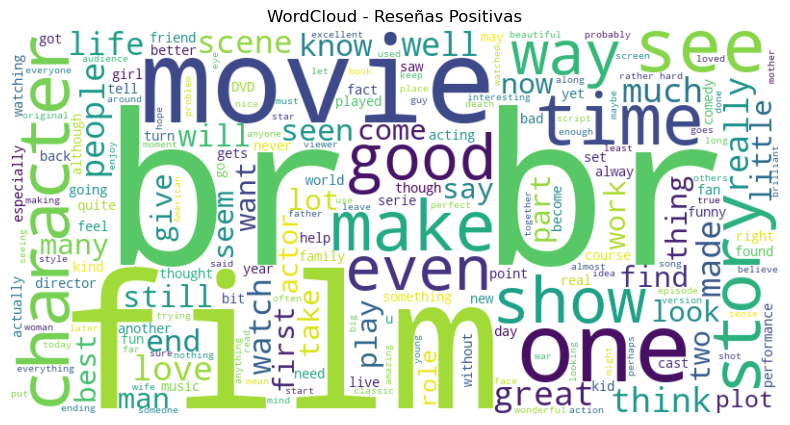

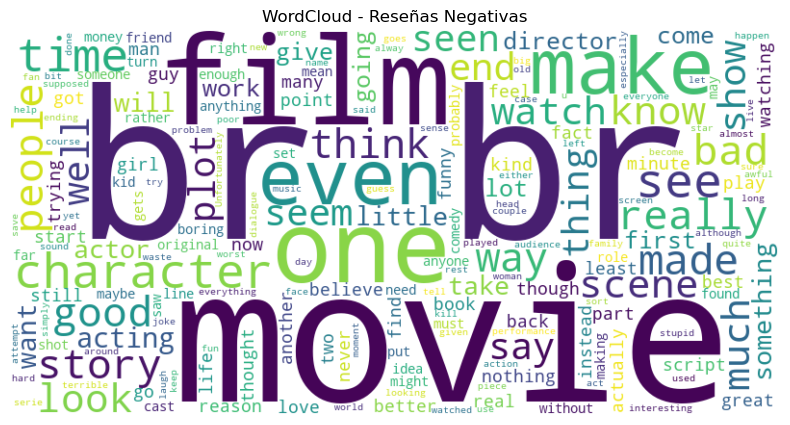

In [16]:
# ==========================================
# 6. Palabras más frecuentes por sentimiento
# ==========================================
# Función para juntar todas las reseñas de un sentimiento
def get_text_by_sentiment(sentiment_label):
    return " ".join(df[df['sentiment']==sentiment_label]['review'].astype(str))

positive_text = get_text_by_sentiment('positive')
negative_text = get_text_by_sentiment('negative')

# ========================================
# 7. WordCloud de palabras más frecuentes
# ========================================
cloud_stopwords = set(STOPWORDS)

# WordCloud positiva
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', stopwords=cloud_stopwords).generate(positive_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Reseñas Positivas")
plt.show()

# WordCloud negativa
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', stopwords=cloud_stopwords).generate(negative_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Reseñas Negativas")
plt.show()

La visualización mediante **nubes de palabras** permite observar de forma rápida las expresiones más utilizadas en las reseñas positivas y negativas.  En ambas clases destacan términos del dominio cinematográfico como *movie*, *film* o *story*, lo cual era esperable dado el contexto del corpus.  

En las reseñas **positivas** predominan adjetivos con carga emocional favorable, tales como *good*, *great*, *love*, *enjoyed* o *best*, mientras que en las **negativas** aparecen con mayor frecuencia *bad*, *boring*, *worst*, *awful* o *waste*.  Estos patrones léxicos reflejan una **polaridad semántica clara** entre ambas clases, lo que facilita la tarea de clasificación.

Se observa también la presencia destacada del token **“br”**, que proviene de las etiquetas HTML `<br />` utilizadas como saltos de línea en el texto original.  Este hallazgo confirma la necesidad de aplicar una **limpieza adicional** durante el preprocesamiento para eliminar dichos residuos de formato, junto con la normalización de mayúsculas, puntuación y espacios.

<div id="estadisticapalabras" class="anchor"></div>
<h3>2.2. Análisis Estadístico de las Palabras</h3>

Hemos realizado un análisis general, por lo que en el siguiente análisis realizaremos un análisis un poco más detallado de las palabras en el dataset:

* Comparación de palabras clave (good, bad, boring, excellent, etc.)
* Top 40 palabras más frecuentes por sentimiento.

In [17]:
# ===============================
# 1. Frecuencia de palabras clave
# ===============================
# Este bloque calcula cuántas veces aparecen ciertas palabras clave
# en todas las reseñas del dataset de IMDB.

# -----------------------------
# Función para limpiar el texto
# -----------------------------
def clean_text(text):
    """
    Esta función recibe un texto y:
    1. Elimina todos los caracteres que NO sean letras o espacios.
    2. Convierte todo el texto a minúsculas.
    Esto facilita contar palabras sin importar mayúsculas, signos de puntuación o caracteres extraños.
    """
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))  # reemplaza todo lo que no sea letra o espacio por ''
    return text.lower()  # convierte a minúsculas

# Aplicamos la función de limpieza a la columna 'review' del DataFrame
# y guardamos el resultado en una nueva columna 'clean_review'
df['clean_review'] = df['review'].apply(clean_text)

# ----------------------------------
# Lista de palabras clave a analizar
# ----------------------------------
# Estas son las palabras que queremos contar en todas las reseñas
keywords = [
    'film', 'movie', 'make', 'character', 'one', 'made', 'even', 'well', 'time', 'story', 
    'show', 'really', 'good', 'bad', 'great', 'terrible', 'boring', 'excellent', 'awful', 'amazing'
]

# Creamos un diccionario vacío para guardar los conteos de cada palabra
keyword_counts = {}

# ------------------------------------------
# Contar la frecuencia de cada palabra clave
# ------------------------------------------
for word in keywords:
    # Para cada palabra:
    # - df['clean_review'].str.count(...) cuenta cuántas veces aparece la palabra en cada reseña
    # - sum() suma los conteos de todas las reseñas, obteniendo el total en el dataset
    keyword_counts[word] = df['clean_review'].str.count(r'\b' + word + r'\b').sum()
    # Nota: \b asegura que contemos la palabra completa y no partes de otras palabras

# -----------------------------------------------------
# Ordenar las palabras clave por frecuencia descendente
# -----------------------------------------------------
# keyword_counts.items() devuelve pares (palabra, conteo)
# sorted(..., key=lambda x: x[1], reverse=True) ordena por el segundo elemento (el conteo) de mayor a menor
sorted_counts = sorted(keyword_counts.items(), key=lambda x: x[1], reverse=True)

# ------------------
# Mostrar resultados
# ------------------
print("\nFrecuencia total de palabras clave (orden descendente):")
for k, v in sorted_counts:
    # Imprime cada palabra junto con su frecuencia total
    print(f"{k}: {v}")


Frecuencia total de palabras clave (orden descendente):
movie: 83523
film: 74459
one: 51028
good: 28570
even: 24576
time: 23269
really: 22951
story: 22097
well: 18798
great: 17821
bad: 17719
made: 15416
make: 15305
character: 12922
show: 12029
excellent: 4019
boring: 3478
terrible: 3220
awful: 3207
amazing: 2445


Explicaciones a considerar:

* `re.sub(r'[^a-zA-Z\s]', '', str(text))`: limpia caracteres no deseados. Por ejemplo, "Movie!" → "Movie".
* `\bword\b` en el `count` asegura que no cuente "story" dentro de "mystory".
* Guardar el texto limpio en una columna nueva evita modificar el original y permite hacer análisis adicionales sin perder datos.

Además:

* `keyword_counts.items()` → obtiene todos los pares palabra:conteo.
* `key=lambda x: x[1]` → indica que la ordenación se basa en el conteo (el valor, no la palabra).
* `reverse=True` → asegura que el orden sea de mayor a menor.


El proceso de limpieza permitió transformar las reseñas en un formato más uniforme, eliminando caracteres no deseados, mayúsculas y signos de puntuación. De este modo, se redujo el ruido textual y se preservó únicamente la información semántica útil para el análisis de sentimientos.

El conteo de las palabras más relevantes evidencia que el vocabulario del corpus combina términos **neutros o de dominio** (*film, movie, character, story*) con otros **marcadamente afectivos** (*good, bad, great, boring, excellent*). Entre los más frecuentes destacan *movie* (83.523 apariciones) y *film* (74.459), lo cual refleja el contexto cinematográfico del conjunto. Asimismo, adjetivos como *good* (28.570) y *bad* (17.719) muestran una clara **polaridad emocional**, lo que confirma que los textos contienen señales léxicas suficientes para entrenar modelos de clasificación.

Este análisis es fundamental porque permite **identificar el tipo de vocabulario que diferencia las clases** y evaluar si los métodos de representación (como TF-IDF o embeddings) podrán capturar estas diferencias de manera efectiva. En resumen, la limpieza y el conteo de palabras clave constituyen la base sobre la cual se construyen las etapas posteriores de modelado y comparación de enfoques.


Veamos ahora un análisis gráfico de los resultados anteriores:

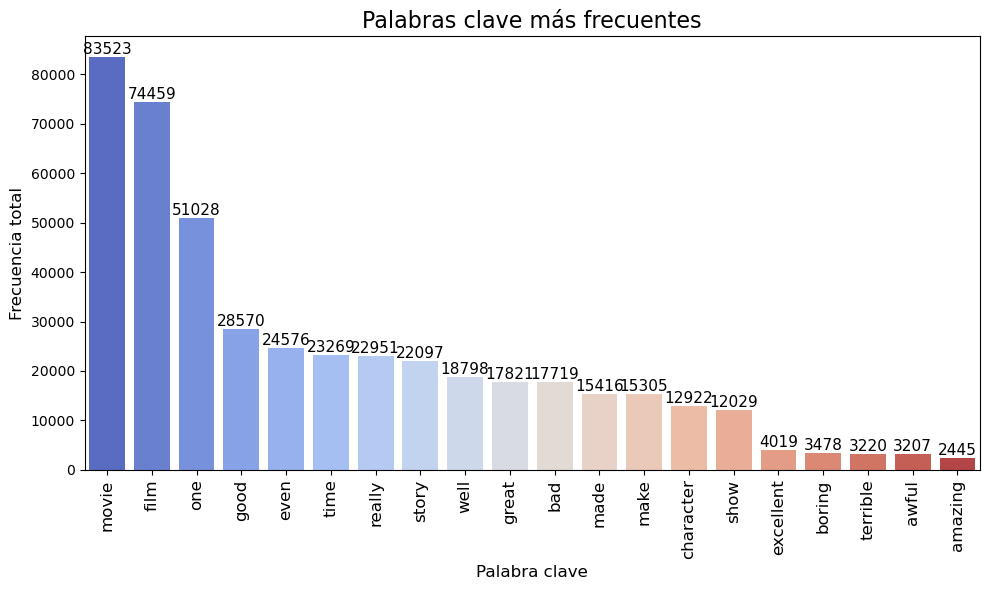

In [18]:
# ----------------------------
# Tomar las palabras escogidas
# -----------------------------
# Separar palabras y valores en dos listas
top_words = [item[0] for item in sorted_counts]
top_counts = [item[1] for item in sorted_counts]

# -------------------------------
# Crear un DataFrame temporal para seaborn
# -------------------------------
df_plot = pd.DataFrame({
    'Palabra': top_words,
    'Frecuencia': top_counts
})

# -------------------------------
# Graficar con Seaborn usando 'hue' para evitar el warning
# -------------------------------
plt.figure(figsize=(10,6))
bars = sns.barplot(
    data=df_plot,
    x='Palabra',
    y='Frecuencia',
    hue='Palabra',        # usamos 'hue' para que la paleta funcione
    dodge=False,           # evita duplicar barras
    palette="coolwarm",    # paleta degradada
    legend=False           # ocultamos la leyenda que aparece por hue
)

# Rotar etiquetas del eje X
plt.xticks(rotation=90, fontsize=12)

# Títulos y etiquetas
plt.title(f"Palabras clave más frecuentes", fontsize=16)
plt.xlabel("Palabra clave", fontsize=12)
plt.ylabel("Frecuencia total", fontsize=12)

# Agregar etiquetas encima de cada barra
for bar in bars.patches:
    height = bar.get_height()
    plt.text(
        x=bar.get_x() + bar.get_width() / 2,
        y=height + 5,
        s=f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()

El gráfico de barras permite visualizar de manera clara la distribución de las palabras más utilizadas en el conjunto de reseñas.  
Se observa que los términos **“movie”** y **“film”** dominan ampliamente el vocabulario, seguidos por palabras que expresan valoraciones o descripciones generales como *good*, *bad*, *great*, *boring* y *excellent*.  

Estos resultados confirman la existencia de dos grupos bien diferenciados:
- **Palabras de dominio:** hacen referencia a elementos propios del cine (*movie*, *film*, *character*, *story*).  
- **Palabras afectivas:** expresan juicio o sentimiento del espectador (*good*, *bad*, *amazing*, *awful*).  

El predominio de estos términos sugiere que las reseñas combinan **descripciones objetivas** con **evaluaciones subjetivas**, lo cual enriquece el problema de clasificación de sentimientos. Además, se destaca que los adjetivos presentan una frecuencia suficiente como para influir de forma significativa en el desempeño de los modelos basados en representación textual (como **TF-IDF** o **embeddings**).  

En conjunto, este análisis reafirma que el corpus está bien estructurado y que contiene un **vocabulario polarizado y semánticamente rico**, condición ideal para los algoritmos de clasificación supervisada que se aplicarán posteriormente.


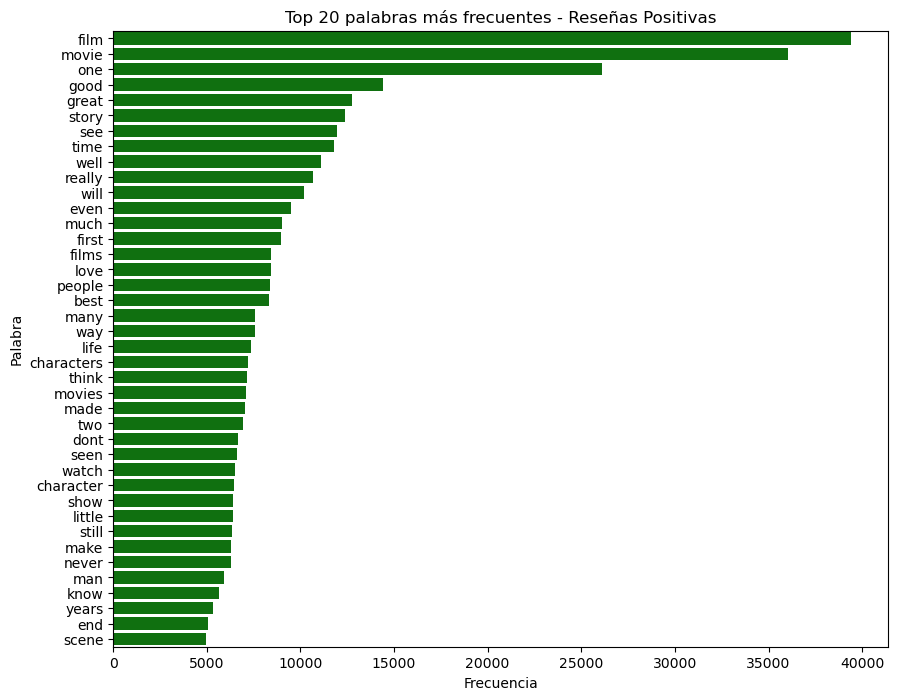

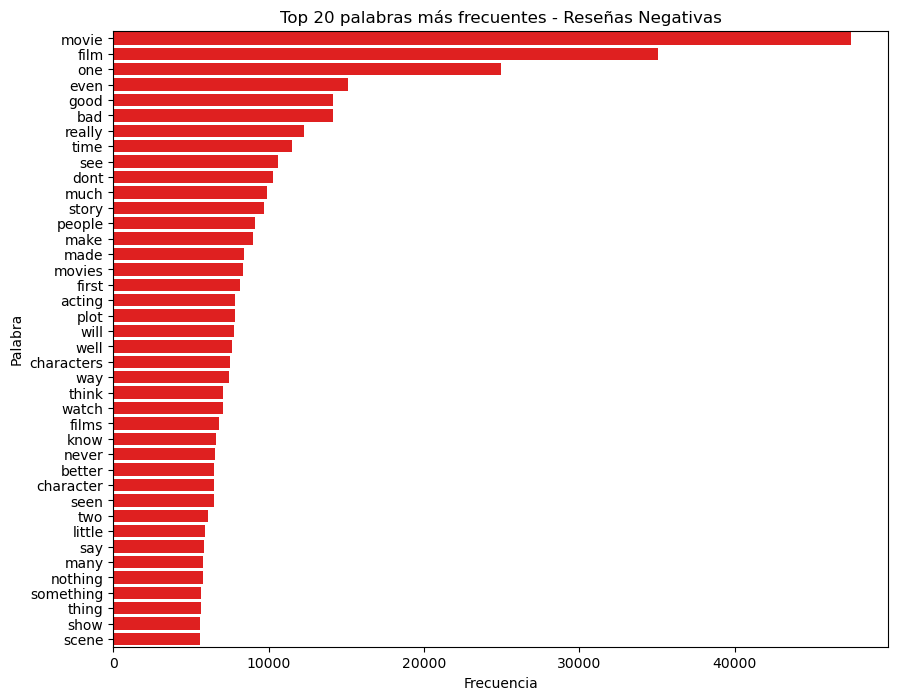

In [19]:
# =================================================
# 2. Top 40 palabras más frecuentes por sentimiento
# =================================================
def get_top_words(sentiment, n=40):
    text = " ".join(df[df['sentiment']==sentiment]['clean_review'])
    words = text.split()
    counter = Counter(words)
    # Remover stopwords
    filtered = {w: c for w, c in counter.items() if w not in cloud_stopwords and len(w)>2}
    return Counter(filtered).most_common(n)

top_pos = get_top_words('positive', 40)
top_neg = get_top_words('negative', 40)

# Crear DataFrame para graficar
df_top_pos = pd.DataFrame(top_pos, columns=['word','count'])
df_top_neg = pd.DataFrame(top_neg, columns=['word','count'])

# Gráfico para positivas
plt.figure(figsize=(10,8))
sns.barplot(data=df_top_pos, x='count', y='word', color='green')
plt.title("Top 20 palabras más frecuentes - Reseñas Positivas")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.show()

# Gráfico para negativas
plt.figure(figsize=(10,8))
sns.barplot(data=df_top_neg, x='count', y='word', color='red')
plt.title("Top 20 palabras más frecuentes - Reseñas Negativas")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.show()

El análisis de las palabras más frecuentes por clase permite identificar los **núcleos léxicos** que caracterizan a cada tipo de reseña.  

En las reseñas **positivas** predominan términos con connotación favorable, como *good*, *great*, *love*, *best*, *enjoyed* o *amazing*.  
Estas palabras reflejan satisfacción y entusiasmo, y suelen asociarse a descripciones detalladas de actuaciones, guiones o experiencias agradables.  

Por el contrario, las reseñas **negativas** concentran vocabulario con carga emocional adversa, como *bad*, *boring*, *worst*, *awful*, *waste* o *nothing*. Estos términos expresan desaprobación y decepción, y tienden a aparecer en textos más breves y directos.  

La comparación entre ambos grupos revela una **polaridad semántica bien definida**, lo que sugiere que el corpus es altamente separable desde el punto de vista léxico.  Esto anticipa que modelos basados en frecuencia de palabras (como **TF-IDF + Regresión Logística**) deberían lograr un rendimiento adecuado.  Sin embargo, para capturar matices más sutiles —como **negaciones** (*“not good”*) o **expresiones contextuales** (*“so bad it’s good”*)— será necesario recurrir a **representaciones con embeddings**, que codifican relaciones semánticas más profundas entre palabras.

En síntesis, este análisis evidencia que las diferencias entre reseñas positivas y negativas son tanto **cuantitativas** (frecuencia de términos) como **cualitativas** (tipo de vocabulario utilizado), lo que valida la elección de este dataset para experimentos de clasificación de sentimientos.


### Conclusión general del Análisis Exploratorio (EDA)

El análisis exploratorio permitió comprender en profundidad la estructura y el contenido del dataset de **50.000 reseñas de películas de IMDB**, confirmando su idoneidad para el estudio de **clasificación de sentimientos**.

En primer lugar, se verificó que el conjunto de datos está **limpio, balanceado y sin valores nulos**, lo que garantiza una base sólida para el modelado.  
Las reseñas presentan una **longitud promedio de unas 230 palabras**, con una ligera tendencia a que las opiniones **positivas sean más extensas** y detalladas, mientras que las **negativas son más concisas** y directas.

El análisis de las palabras más frecuentes mostró la coexistencia de **términos de dominio cinematográfico** (*movie*, *film*, *story*) con **términos valorativos** que reflejan la opinión del espectador (*good*, *bad*, *great*, *boring*, *excellent*).  
Las **nubes de palabras** y los **gráficos de frecuencia** evidenciaron una clara **polaridad léxica**, lo que sugiere que las diferencias entre clases pueden captarse mediante modelos supervisados.

Asimismo, se detectó la presencia de **ruido textual** (como etiquetas HTML `<br />` y puntuación adherida a las palabras), que deberá ser eliminado en la etapa de **preprocesamiento** para evitar errores en la tokenización y en la representación vectorial.

En conjunto, los resultados del EDA permiten concluir que el dataset:

- Está **balanceado y depurado**.  
- Contiene un **vocabulario polarizado y semánticamente rico**, favorable para la tarea de clasificación.  
- Requiere una **etapa de limpieza textual** para eliminar ruido residual.  
- Permite abordar comparaciones entre representaciones **TF-IDF** y **embeddings**, al contar con suficiente información contextual y emocional.

Este análisis preliminar proporciona una visión clara de las características del corpus y orienta las decisiones metodológicas que se aplicarán en las siguientes etapas del trabajo.


<div id="preprocesamiento" class="anchor"></div>
<h2>3. Preprocesamiento del texto</h2>

Luego del análisis exploratorio realizado sobre el conjunto de reseñas de IMDB, el siguiente paso consiste en aplicar un proceso de **preprocesamiento textual**.  
El objetivo principal de esta etapa es **limpiar, normalizar y preparar los textos** para que puedan ser representados de manera numérica en etapas posteriores de modelado.

El preprocesamiento busca reducir el **ruido léxico** presente en las reseñas —como etiquetas HTML (`<br />`), signos de puntuación, mayúsculas o espacios innecesarios— y transformar las oraciones en un formato uniforme que facilite la extracción de información relevante.

Entre las tareas aplicadas se incluyen:

- Eliminación de etiquetas HTML y caracteres no alfabéticos.  
- Conversión de todo el texto a minúsculas.  
- Tokenización (separación de palabras individuales).  
- Eliminación de *stopwords* (palabras sin carga semántica relevante).  
- Lematización o reducción de palabras a su forma base.  

El resultado de este proceso es un corpus **limpio y homogéneo**, en el cual las palabras conservan su significado esencial, eliminando variaciones innecesarias.  
De este modo, el texto queda adecuadamente preparado para ser transformado en representaciones numéricas (como TF-IDF o embeddings) y, eventualmente, utilizado en tareas de clasificación de sentimientos.


A continuación se detallan los pasos realizados para preparar las reseñas:
1. Descarga de recursos de `nltk` (diccionarios y stopwords).  
2. Limpieza y normalización del texto.  
3. Tokenización y eliminación de stopwords.  
4. Lematización.  
5. Codificación de las etiquetas de sentimiento en formato binario (positivo = 1, negativo = 0).

In [20]:
# Primero, descargamos los recursos de la librería de NLTK que utilizaremos:

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /home/dalma/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/dalma/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/dalma/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

Se descargan los recursos necesarios de `nltk` para:
- **stopwords**: lista de palabras muy frecuentes sin carga semántica relevante.
- **wordnet** y **omw-1.4**: diccionarios para **lematización** (reducir palabras a su forma base).

Para evitar errores en el preprocesamieto del dataset, volvemos a cargarlo desde la carpeta donde hemos realizado una copia del dataset original.

In [21]:
# -------------------------------------------
# Definir la carpeta local donde está el CSV
# ------------------------------------------
local_folder = "imdb_dataset"  # carpeta local

# ------------------------------------------
# Buscar el primer archivo CSV en la carpeta
# ------------------------------------------
csv_file = None
for f in os.listdir(local_folder):
    if f.endswith(".csv"):  # buscamos archivos que terminen en .csv
        csv_file = os.path.join(local_folder, f)
        break

# Verificamos si se encontró el archivo
if csv_file is None:
    raise FileNotFoundError(f"No se encontró ningún archivo CSV en la carpeta: {local_folder}")
else:
    print(f"Archivo CSV encontrado y listo para cargar: {csv_file}")

# -----------------------------
# Cargar el CSV en un DataFrame
# -----------------------------
df = pd.read_csv(csv_file)

Archivo CSV encontrado y listo para cargar: imdb_dataset/IMDB Dataset.csv


Luego, definimos una función de preprocesamiento del texto y lo aplicamos. Además, codificamos las etiquetas tal que:

* positive: 1
* negative: 0

In [22]:
# ============================
# 1. Preprocesamiento de texto
# ============================
def preprocess_text(text):
    """
    Esta función realiza varias operaciones de limpieza y normalización de texto:
    1. Convierte todo a minúsculas.
    2. Elimina caracteres que no sean letras.
    3. Tokeniza el texto en palabras.
    4. Elimina stopwords (palabras muy comunes que no aportan significado).
    5. Lematiza cada palabra (reduce a su forma base).
    6. Devuelve el texto procesado como un solo string.
    """
    
    # ---------------------------
    # Convertir todo el texto a minúsculas
    # Esto asegura que 'Movie' y 'movie' se traten igual
    text = text.lower()
    
    # ---------------------------
    # Eliminar caracteres que no sean letras (a-z) o espacios
    # Por ejemplo, elimina números, puntuación, símbolos
    text = re.sub(r'[^a-z\s]', '', text)
    
    # ---------------------------
    # Tokenizar: separar el texto en palabras individuales
    # 'This is good' -> ['this', 'is', 'good']
    words = text.split()
    
    # ---------------------------
    # Eliminar stopwords (palabras muy comunes que no aportan mucho significado)
    # Ejemplo: 'the', 'and', 'is', etc.
    english_stopwords = set(stopwords.words('english'))
    words = [w for w in words if w not in english_stopwords]
    
    # ---------------------------
    # Lematizar: reducir cada palabra a su forma base
    # Ejemplo: 'running' -> 'run', 'better' -> 'good'
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(w) for w in words]
    
    # ---------------------------
    # Volver a unir las palabras en un solo string
    # ['good', 'movie'] -> 'good movie'
    return " ".join(words)

# Aplicar preprocesamiento (esto puede tardar un poco)
df['clean_review'] = df['review'].apply(preprocess_text)

# Imprimo el texto sinlimiar y el limpio
print("Ejemplo de texto limpio:")
print(df[['review', 'clean_review']].head(20))

# ======================
# 2. Codificar etiquetas
# ======================
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

Ejemplo de texto limpio:
                                               review  \
0   One of the other reviewers has mentioned that ...   
1   A wonderful little production. <br /><br />The...   
2   I thought this was a wonderful way to spend ti...   
3   Basically there's a family where a little boy ...   
4   Petter Mattei's "Love in the Time of Money" is...   
5   Probably my all-time favorite movie, a story o...   
6   I sure would like to see a resurrection of a u...   
7   This show was an amazing, fresh & innovative i...   
8   Encouraged by the positive comments about this...   
9   If you like original gut wrenching laughter yo...   
10  Phil the Alien is one of those quirky films wh...   
11  I saw this movie when I was about 12 when it c...   
12  So im not a big fan of Boll's work but then ag...   
13  The cast played Shakespeare.<br /><br />Shakes...   
14  This a fantastic movie of three prisoners who ...   
15  Kind of drawn in by the erotic scenes, only to...   
16  So

El proceso de preprocesamiento tiene como objetivo **limpiar, normalizar y estandarizar** las reseñas para reducir el ruido textual y unificar el vocabulario. Sobre cada documento se aplican las siguientes etapas:

- **Minúsculas** (`text.lower()`): unifica la capitalización y evita duplicidades entre tokens equivalentes (*Movie* vs. *movie*).
- **Eliminación de caracteres no alfabéticos** (`re.sub(r'[^a-z\s]', '', text)`): remueve signos de puntuación, números, etiquetas HTML y símbolos, preservando solo letras y espacios.
- **Tokenización** (`text.split()`): segmenta el texto en **palabras individuales**, habilitando el filtrado y la normalización por término.
- **Eliminación de *stopwords*** (lista en inglés de `nltk`): descarta palabras funcionales muy frecuentes (p. ej., *the*, *and*, *is*) sin aporte semántico relevante para el sentimiento.
- **Lematización** (`WordNetLemmatizer`): reduce cada palabra a su **forma base** (p. ej., *running → run*, *characters → character*), consolidando variantes morfológicas.
- **Reconstrucción** (`" ".join(words)`): recompone las palabras procesadas en un único string limpio, apto para su vectorización posterior.

In [23]:
# -------------------------------
# Función de preprocesamiento paso a paso
# -------------------------------
def preprocess_step_by_step(text):
    print("Texto original:")
    print(text)
    print("\n---------------------------")
    
    # 1. Convertir a minúsculas
    text_lower = text.lower()
    print("Texto en minúsculas:")
    print(text_lower)
    print("\n---------------------------")
    
    # 2. Eliminar caracteres no alfabéticos
    text_alpha = re.sub(r'[^a-z\s]', '', text_lower)
    print("Texto sin caracteres especiales:")
    print(text_alpha)
    print("\n---------------------------")
    
    # 3. Tokenizar
    words = text_alpha.split()
    print("Tokenización (lista de palabras):")
    print(words)
    print("\n---------------------------")
    
    # 4. Eliminar stopwords
    stop_words = set(stopwords.words('english'))
    words_no_stop = [w for w in words if w not in stop_words]
    print("Después de eliminar stopwords:")
    print(words_no_stop)
    print("\n---------------------------")
    
    # 5. Lematización
    lemmatizer = WordNetLemmatizer()
    words_lemmatized = [lemmatizer.lemmatize(w) for w in words_no_stop]
    print("Después de lematizar:")
    print(words_lemmatized)
    print("\n---------------------------")
    
    # 6. Volver a unir palabras
    final_text = " ".join(words_lemmatized)
    print("Texto final procesado:")
    print(final_text)
    print("\n===========================\n")
    
    return final_text

# ----------------------
# Ejemplo real de reseña
# ----------------------
review_example = "The movie was AMAZING! I loved the characters and the story, even though it was a bit long."
processed_review = preprocess_step_by_step(review_example)

Texto original:
The movie was AMAZING! I loved the characters and the story, even though it was a bit long.

---------------------------
Texto en minúsculas:
the movie was amazing! i loved the characters and the story, even though it was a bit long.

---------------------------
Texto sin caracteres especiales:
the movie was amazing i loved the characters and the story even though it was a bit long

---------------------------
Tokenización (lista de palabras):
['the', 'movie', 'was', 'amazing', 'i', 'loved', 'the', 'characters', 'and', 'the', 'story', 'even', 'though', 'it', 'was', 'a', 'bit', 'long']

---------------------------
Después de eliminar stopwords:
['movie', 'amazing', 'loved', 'characters', 'story', 'even', 'though', 'bit', 'long']

---------------------------
Después de lematizar:
['movie', 'amazing', 'loved', 'character', 'story', 'even', 'though', 'bit', 'long']

---------------------------
Texto final procesado:
movie amazing loved character story even though bit long



Una vez preprocesados el texto, procedemos a crear el conjunto de entrenamiento y validación: 

In [24]:
# ======================
# 3. División train-test
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'], 
    df['label'],
    test_size=0.2, 
    random_state=42, 
    stratify=df['label']
)

print(f"Tamaño de entrenamiento: {len(X_train)}")
print(f"Tamaño de prueba: {len(X_test)}")

Tamaño de entrenamiento: 40000
Tamaño de prueba: 10000


Luego, vectorizamos el DataFrame.

In [25]:
# =======================
# 4. Vectorización TF-IDF
# =======================
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Tamaño del vocabulario TF-IDF:", len(vectorizer.get_feature_names_out()))

Tamaño del vocabulario TF-IDF: 10000


<div id="TF-IDF" class="anchor"></div>
<h3>3.1. Representación vectorial con TF-IDF</h3>

Para representar las reseñas de manera numérica se utilizó el método **TF-IDF (Term Frequency – Inverse Document Frequency)**, ampliamente empleado en **recuperación de información**, **minería de textos** y **procesamiento del lenguaje natural (NLP)**.  
Su propósito es **convertir documentos de texto en vectores numéricos**, asignando a cada palabra un peso proporcional a su **relevancia dentro del documento** y su **rareza en el corpus completo**.

####  Configuración empleada
- `max_features = 10 000`: limita el vocabulario a las 10 000 palabras más informativas, equilibrando cobertura y eficiencia.  
- `ngram_range = (1, 2)`: considera unigramas y bigramas para capturar expresiones compuestas (*not good*, *very bad*).  
- Ajuste realizado sobre el **conjunto de entrenamiento** y transformación sobre el **de validación**, evitando fuga de información (*data leakage*).


###  Fundamentos teóricos del método TF-IDF

TF-IDF combina dos conceptos fundamentales:

#### a) TF (Term Frequency) – Frecuencia de término

Representa la frecuencia de una palabra en un documento.

> Cuanto más veces aparece una palabra en un documento, mayor será su TF.

**Fórmula habitual:**

$$
TF(t, d) = \frac{\text{Número de veces que aparece el término } t \text{ en el documento } d}{\text{Número total de palabras en el documento } d}
$$

**Ejemplo:**

Si el documento dice:  
`"the movie was good and the movie was long"`

- Total de palabras: 8  
- Frecuencia de `"movie"`: 2  

$$
TF("movie") = \frac{2}{8} = 0.25
$$

#### b) IDF (Inverse Document Frequency) – Frecuencia inversa de documentos

Mide qué tan **rara o común** es una palabra en todo el corpus.

> Las palabras muy comunes (como “the”, “and”) reciben menor importancia,  
> mientras que palabras raras o específicas reciben mayor peso.

**Fórmula:**

$$
IDF(t) = \log \left( \frac{N}{1 + n_t} \right)
$$

Donde:

- $N$: número total de documentos en el corpus.  
- $n_t$: número de documentos que contienen el término $t$.  
- Se añade **1** en el denominador para evitar división por cero.

**Ejemplo:**

Si tenemos 1000 reseñas y `"movie"` aparece en 900 de ellas:

$$
IDF("movie") = \log \left( \frac{1000}{1 + 900} \right) \approx 0.105
$$

En cambio, una palabra rara como `"masterpiece"` que aparece en solo 5 documentos tendrá:

$$
IDF("masterpiece") = \log \left( \frac{1000}{1 + 5} \right) \approx 5.2
$$

### TF-IDF: combinación de ambos

Finalmente, el peso TF-IDF se obtiene multiplicando **TF** por **IDF**:

$$
TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t)
$$

Esto significa que una palabra tiene un alto valor TF-IDF si:

- Aparece **con frecuencia** en un documento,  
- Pero es **rara** en el resto del corpus.

**Ejemplo conceptual:**

| Palabra      | TF     | IDF   | TF-IDF  |
|---------------|--------|-------|----------|
| movie         | 0.25   | 0.105 | 0.02625  |
| masterpiece   | 0.125  | 5.2   | 0.65     |

*Observación:* `"masterpiece"` es mucho más significativa para el documento que `"movie"`.

---

#### Representación vectorial

Cada documento se representa como un **vector en un espacio de alta dimensión**, donde cada dimensión corresponde a una palabra del vocabulario.

> Si tenemos 10,000 palabras únicas en el corpus,  
> cada documento será un vector de 10,000 dimensiones con los valores TF-IDF de cada palabra.

Esto permite usar algoritmos de Machine Learning como:

- Regresión Logística  
- SVM  
- Random Forest  
- Redes Neuronales

**Ventaja:** la representación TF-IDF captura la **importancia relativa** de las palabras, a diferencia de un simple conteo.

#### Propiedades importantes

- **Sparsity (escasez):** los vectores resultan muy dispersos, ya que cada documento contiene solo una fracción del vocabulario total.  
- **Modelo *bag-of-words*:** no considera el orden de las palabras ni su contexto sintáctico.  
- **Escalabilidad:** puede aplicarse a corpus extensos de forma eficiente.  
- **Interpretabilidad:** los coeficientes de modelos lineales entrenados con TF-IDF permiten identificar qué palabras son más influyentes en cada clase.


#### Aplicaciones

Esto convierte a TF-IDF en una herramienta útil para ser utilizadas en diferentes casos:

- **Clasificación de texto:** spam vs. no spam, análisis de sentimientos (nuestro problema), categorización de noticias.  
- **Búsqueda de información:** motores de búsqueda, ranking de documentos según relevancia.  
- **Detección de temas y keywords:** extracción de palabras clave más representativas de un corpus.

---

#### En resumen

TF-IDF transforma texto en números de forma que:

- Aumenta el peso de las palabras **relevantes y distintivas**,  
- Reduce el peso de las palabras **comunes y poco informativas**.

Es una técnica **sencilla, interpretable y eficaz** que sirve como punto de partida fundamental para muchos modelos de NLP.

---

A continuación, veamos algunas de estas características sobre nuestro conjunto de datos:

In [26]:
# ---------------------------------------------
# Examinar el vector TF-IDF de la primera frase
# ---------------------------------------------
# X_train_tfidf[0] es un vector disperso que representa la primera frase
print("Vector TF-IDF de la primera frase (disperso):")
print(X_train_tfidf[0])

Vector TF-IDF de la primera frase (disperso):
  (0, 1417)	0.1058294121838355
  (0, 5167)	0.05775524723500348
  (0, 3705)	0.11154354540951966
  (0, 9089)	0.08730634586338186
  (0, 43)	0.11748645144101191
  (0, 592)	0.06289218226689249
  (0, 8832)	0.2334598144422638
  (0, 7816)	0.09121385896933124
  (0, 9226)	0.057595185047295445
  (0, 6310)	0.06701442719678362
  (0, 8067)	0.192870146306482
  (0, 7750)	0.21377127378656605
  (0, 5774)	0.031313598838058794
  (0, 6526)	0.1360261689697463
  (0, 3638)	0.08339124553896635
  (0, 9552)	0.11850647495094314
  (0, 8037)	0.22048249937778372
  (0, 1248)	0.09840608980328391
  (0, 8006)	0.08180971436786523
  (0, 8329)	0.12945449648870255
  (0, 3733)	0.04601837794616096
  (0, 5738)	0.10947711228010591
  (0, 8227)	0.0947075540580596
  (0, 322)	0.10889073582875268
  (0, 1292)	0.16432231145355697
  :	:
  (0, 1944)	0.08427145725070766
  (0, 8452)	0.09036624750378808
  (0, 4971)	0.10598859166767938
  (0, 2302)	0.16866024959905862
  (0, 4972)	0.12590477037811

In [27]:
# ----------------------------------------
# Convertir el vector disperso a DataFrame
# ----------------------------------------
# Esto facilita ver qué palabras tienen mayor importancia
# .T convierte el vector fila en columna
# .todense() transforma de sparse matrix a matriz densa
df0 = pd.DataFrame(
    X_train_tfidf[0].T.todense(),            # matriz densa de TF-IDF
    index=vectorizer.get_feature_names_out(),     # nombres de las palabras
    columns=["TF-IDF"]                       # columna con valores TF-IDF
)

# ---------------------------------------------
# Ordenar las palabras por TF-IDF (descendente)
# ---------------------------------------------
df0_sorted = df0.sort_values('TF-IDF', ascending=False)

# ------------------
# Mostrar resultados
# ------------------
print("\nPalabras ordenadas por importancia (TF-IDF) en la primera frase:")
print(df0_sorted)


Palabras ordenadas por importancia (TF-IDF) en la primera frase:
                TF-IDF
theatre       0.233460
showed        0.220482
scifi         0.213771
silly         0.192870
dialogue      0.168660
...                ...
film open     0.000000
film people   0.000000
film perhaps  0.000000
film play     0.000000
zoom          0.000000

[10000 rows x 1 columns]


In [28]:
# ---------------------
# Información adicional
# ---------------------
# Número de palabras consideradas en la frase
print("\nNúmero de palabras en el vector TF-IDF:", df0.shape[0])

# Forma del DataFrame
print("Forma del DataFrame (palabras x columnas):", df0_sorted.shape)


Número de palabras en el vector TF-IDF: 10000
Forma del DataFrame (palabras x columnas): (10000, 1)


<div id="EMBEDDINGS" class="anchor"></div>
<h3>3.2. Representación semántica mediante Word Embeddings</h3>


Como complemento al modelo **TF-IDF** —que representa cada documento como una bolsa de palabras ponderadas en función de su frecuencia—, se incorporó una representación **semántica continua** basada en **word embeddings**.  
Este enfoque busca capturar las **relaciones de significado y contexto** entre palabras, superando la limitación del modelo de bolsa de palabras (*bag-of-words*), que trata los términos como unidades independientes.


###  Concepto general

Un *embedding* es una representación **vectorial densa y continua** de las palabras, en la que cada término se mapea a un punto en un espacio de dimensiones reducidas (por ejemplo, 100 o 300).  
A diferencia de TF-IDF —que mide la importancia estadística de cada palabra—, los *embeddings* se construyen a partir del **contexto lingüístico**: palabras que aparecen en **entornos similares** tienden a tener **vectores cercanos** en dicho espacio.

Esta idea se fundamenta en la **hipótesis distribucional** de la lingüística computacional:

> “Palabras que aparecen en contextos similares tienden a tener significados similares.”  
> *(Harris, 1954)*

De esta manera, los *embeddings* aprenden patrones semánticos y sintácticos a partir de la coocurrencia de palabras en grandes corpus de texto.  
Así, relaciones de analogía pueden representarse de forma vectorial, por ejemplo:

$$
\mathbf{v}_{\text{king}} - \mathbf{v}_{\text{man}} + \mathbf{v}_{\text{woman}} \approx \mathbf{v}_{\text{queen}}
$$



Lo anterior refleja que los vectores de palabras **semánticamente relacionadas** se ubican **próximos entre sí** en el espacio embebido, capturando similitudes de género, rol, tiempo verbal, entre otras.

En síntesis, mientras TF-IDF codifica la **presencia e importancia estadística** de las palabras, los *embeddings* codifican su **significado y relaciones semánticas**, lo que los hace especialmente útiles para tareas de **análisis de sentimientos, clasificación, y comprensión del lenguaje natural**.

---

Antes de entrenar el modelo *Word2Vec*, es necesario **tokenizar** las reseñas. Cada texto se divide en una lista de palabras (tokens) que servirán como insumo para el entrenamiento del modelo.  Este paso es equivalente al realizado para TF-IDF, pero aquí los tokens serán tratados como **unidades de contexto** en lugar de simples frecuencias.


In [29]:
# ===============================
# Tokenización para embeddings
# ===============================
# Partimos del split existente (X_train, X_test)
tokenized_train = [txt.split() for txt in X_train]
tokenized_test  = [txt.split() for txt in X_test]

print("Ejemplos tokenizados (train):", tokenized_train[0][:20])


Ejemplos tokenizados (train): ['caught', 'little', 'gem', 'totally', 'accident', 'back', 'revival', 'theatre', 'see', 'two', 'old', 'silly', 'scifi', 'movie', 'theatre', 'packed', 'full', 'warning', 'showed', 'bunch']


Luego entrenamos el modelo **Word2Vec** utilizando únicamente el conjunto de **entrenamiento** (`X_train`) para evitar **data leakage**.  
El modelo aprende representaciones vectoriales de las palabras a partir de su coocurrencia en un contexto definido (`window`).

**Hiperparámetros clave:**
- `vector_size=100`: dimensión de los embeddings.  
- `window=5`: tamaño del contexto local.  
- `min_count=5`: excluye palabras poco frecuentes.  
- `sg=1`: usa el algoritmo **Skip-gram** (mejor para palabras raras).  
- `epochs=5`: número de iteraciones sobre el corpus.


In [30]:
# ==================================
# Entrenamiento de Word2Vec (SG)
# ==================================
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=tokenized_train,  
    vector_size=100,            
    window=5,                   
    min_count=5,                
    sg=1,                       
    workers=4,
    seed=42,
    epochs=5
)

print("Tamaño del vocabulario Word2Vec:", len(w2v_model.wv))


Tamaño del vocabulario Word2Vec: 35719


Cada reseña debe representarse como un **vector numérico** de tamaño fijo para ser utilizada por modelos de aprendizaje.  Para ello, scalculamos el **promedio de los vectores de sus palabras** conocidas por el modelo.  
Este procedimiento produce un vector representativo de la reseña, que resume su significado general.


In [31]:
# =============================================
# Vectores de documento (promedio de palabras)
# =============================================
import numpy as np

def doc_embedding(tokens, model):
    """Devuelve el promedio de los embeddings de las palabras presentes en el vocabulario."""
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if not vecs:
        return np.zeros(model.vector_size, dtype=np.float32)
    return np.mean(vecs, axis=0).astype(np.float32)

X_train_w2v = np.vstack([doc_embedding(tok, w2v_model) for tok in tokenized_train])
X_test_w2v  = np.vstack([doc_embedding(tok, w2v_model) for tok in tokenized_test])

print("Shape X_train_w2v:", X_train_w2v.shape)
print("Shape X_test_w2v :", X_test_w2v.shape)


Shape X_train_w2v: (40000, 100)
Shape X_test_w2v : (10000, 100)


Como verificación cualitativa, exploramios los **vecinos semánticos** de una palabra frecuente (por ejemplo `"good"`).  
El modelo devuelve los términos más cercanos según la **similitud del coseno**, evidenciando las relaciones semánticas aprendidas.


In [32]:
# ===================================
# 5.4 Chequeos rápidos e interpretación
# ===================================
term = "good"
if term in w2v_model.wv:
    print(f"Vecinos semánticos de '{term}':")
    for w, sim in w2v_model.wv.most_similar(term, topn=10):
        print(f"  {w:15s}  sim={sim:.3f}")
else:
    print(f"'{term}' no está en el vocabulario (posible por min_count=5).")


Vecinos semánticos de 'good':
  decent           sim=0.805
  great            sim=0.781
  goodbut          sim=0.777
  suckedbr         sim=0.764
  nice             sim=0.761
  hehe             sim=0.755
  potentialbr      sim=0.753
  bclass           sim=0.751
  bad              sim=0.751
  hotbr            sim=0.751


La implementación de **Word2Vec (Skip-gram, 100 dimensiones)** permitió generar representaciones **densas y continuas** que reflejan similitudes semánticas entre palabras y documentos.  

En conjunto con TF-IDF, el corpus queda descrito mediante dos enfoques complementarios:

| Representación | Tipo de vector | Qué captura | Ventajas |
|----------------|----------------|--------------|-----------|
| **TF-IDF** | Disperso (*sparse*) | Frecuencia e importancia estadística | Alta interpretabilidad |
| **Word2Vec** | Denso (*dense*) | Significado y relaciones semánticas | Captura contexto y analogías |

Estas dos vistas constituyen una base sólida para la etapa de **modelado y comparación de resultados**, cumpliendo con el objetivo de contrastar enfoques tradicionales de NLP frente a representaciones semánticas modernas.


## 4. Modelos básicos de clasificación

En esta sección se busca **comparar el desempeño de distintos algoritmos de clasificación** aplicados a las reseñas del dataset IMDB, previamente representadas mediante **TF-IDF** y **Word Embeddings (Word2Vec)**.  
El objetivo es evaluar cómo varía el rendimiento según el modelo y la representación de texto utilizada.

Se eligieron cinco clasificadores representativos por su desempeño probado en procesamiento de texto:

1. **Regresión Logística (LR)**  
   Modelo lineal robusto para clasificación binaria. Suele ofrecer una excelente línea base en tareas de NLP.

2. **Naive Bayes Multinomial (NB)**  
   Modelo probabilístico simple y eficiente, que asume independencia entre palabras.  
   Destacado por su velocidad y buen rendimiento con texto vectorizado mediante TF-IDF.

3. **Máquinas de Vectores de Soporte (SVM)**  
   Clasificador lineal que busca maximizar el margen entre clases.  
   Es uno de los métodos más utilizados en análisis de sentimientos por su alta capacidad de generalización.

4. **Random Forest (RF)**  
   Conjunto de árboles de decisión que combina múltiples predictores débiles.  
   Permite capturar relaciones no lineales y es menos sensible a outliers.

5. **Red Neuronal Multicapa (MLP)**  
   Modelo de red neuronal feedforward con una o más capas ocultas.  
   Permite aprender representaciones no lineales de los datos; útil cuando se emplean embeddings densos.

Para cada modelo se ajustarán **hiperparámetros clave** mediante búsqueda exhaustiva utilizando `GridSearchCV` y validación cruzada (`KFold`).  
Las métricas empleadas para la comparación serán:

- **Accuracy (Exactitud)**
- **Precision**
- **Recall**
- **F1-score**

La comparación final permitirá analizar qué modelo y qué tipo de representación (TF-IDF vs Word2Vec) resultan más eficaces en la clasificación de sentimientos del corpus IMDB.


In [33]:
# =====================================================
# Funciones auxiliares para evaluar modelos
# =====================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def eval_metrics(y_true, y_pred):
    """Calcula las métricas de desempeño básicas."""
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }

def summarize_results(name, y_true, y_pred, features_tag):
    """Devuelve un diccionario con resultados legibles."""
    m = eval_metrics(y_true, y_pred)
    row = {"Features": features_tag, "Modelo": name}
    row.update({k: round(v, 4) for k, v in m.items()})
    return row


### Modelos entrenados sobre representación TF-IDF

En primer lugar, se entrenan modelos que trabajan eficientemente con **matrices dispersas**, típicas del TF-IDF:

- **Regresión Logística (LR)**
- **Linear SVM (LinearSVC)**
- **Naive Bayes Multinomial (MNB)**

Estos algoritmos son adecuados para datos textuales representados como conteos o pesos de palabras, y se destacan por su velocidad e interpretabilidad.


In [34]:
# ===========================================
# Entrenamiento y evaluación con TF-IDF
# ===========================================
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

tfidf_models = {
    "LogisticRegression": LogisticRegression(solver="liblinear", random_state=42, max_iter=1000),
    "LinearSVC": LinearSVC(random_state=42),
    "MultinomialNB": MultinomialNB()
}

tfidf_grids = {
    "LogisticRegression": {"C": [0.5, 1.0, 2.0]},
    "LinearSVC": {"C": [0.5, 1.0, 2.0]},
    "MultinomialNB": {"alpha": [0.1, 0.5, 1.0]}
}

tfidf_results = []

for name, model in tfidf_models.items():
    gs = GridSearchCV(
        estimator=model,
        param_grid=tfidf_grids[name],
        scoring="f1",
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    gs.fit(X_train_tfidf, y_train)
    best = gs.best_estimator_
    y_pred = best.predict(X_test_tfidf)
    tfidf_results.append(summarize_results(name, y_test, y_pred, "TF-IDF"))
    print(f"[TF-IDF] {name} mejores parámetros: {gs.best_params_}")


Fitting 3 folds for each of 3 candidates, totalling 9 fits
[TF-IDF] LogisticRegression mejores parámetros: {'C': 2.0}
Fitting 3 folds for each of 3 candidates, totalling 9 fits
[TF-IDF] LinearSVC mejores parámetros: {'C': 0.5}
Fitting 3 folds for each of 3 candidates, totalling 9 fits
[TF-IDF] MultinomialNB mejores parámetros: {'alpha': 1.0}


### Modelos entrenados sobre representación por *Word Embeddings*

En esta segunda etapa, se utilizan vectores **densos y semánticos** obtenidos a partir de *Word2Vec*. A diferencia de TF-IDF, los embeddings capturan relaciones de significado entre palabras, por lo que se evalúan modelos capaces de manejar estructuras no lineales:

- **Regresión Logística (LR)**
- **SVM con kernel RBF (SVC)**
- **Random Forest (RF)**
- **Red Neuronal Multicapa (MLP)**
- **Naive Bayes Gaussiano (GNB)**


In [35]:
# ======================================================
# Entrenamiento y evaluación con Word Embeddings
# ======================================================
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

Xtr_w2v = X_train_w2v_std if 'X_train_w2v_std' in globals() else X_train_w2v
Xte_w2v = X_test_w2v_std  if 'X_test_w2v_std'  in globals() else X_test_w2v

embed_models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "SVC_RBF": SVC(kernel="rbf", random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "MLP": MLPClassifier(hidden_layer_sizes=(128,), max_iter=50, random_state=42),
    "GaussianNB": GaussianNB()
}

embed_grids = {
    "LogisticRegression": {"C": [0.5, 1.0, 2.0]},
    "SVC_RBF": {"C": [0.5, 1.0, 2.0], "gamma": ["scale", 0.1]},
    "RandomForest": {"n_estimators": [300, 600], "max_depth": [None, 20]},
    "MLP": {"hidden_layer_sizes": [(128,), (256,)], "alpha": [1e-4, 1e-3]},
    "GaussianNB": {}
}

embed_results = []

for name, model in embed_models.items():
    gs = GridSearchCV(
        estimator=model,
        param_grid=embed_grids[name],
        scoring="f1",
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    gs.fit(Xtr_w2v, y_train)
    best = gs.best_estimator_
    y_pred = best.predict(Xte_w2v)
    embed_results.append(summarize_results(name, y_test, y_pred, "Embeddings"))
    print(f"[Embeddings] {name} mejores parámetros: {gs.best_params_}")


Fitting 3 folds for each of 3 candidates, totalling 9 fits
[Embeddings] LogisticRegression mejores parámetros: {'C': 2.0}
Fitting 3 folds for each of 6 candidates, totalling 18 fits
[Embeddings] SVC_RBF mejores parámetros: {'C': 2.0, 'gamma': 'scale'}
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[Embeddings] RandomForest mejores parámetros: {'max_depth': None, 'n_estimators': 600}
Fitting 3 folds for each of 4 candidates, totalling 12 fits


/home/dalma/miniconda3/envs/diplo_env/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/dalma/miniconda3/envs/diplo_env/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/dalma/miniconda3/envs/diplo_env/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/dalma/miniconda3/envs/diplo_env/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
 

[Embeddings] MLP mejores parámetros: {'alpha': 0.0001, 'hidden_layer_sizes': (128,)}
Fitting 3 folds for each of 1 candidates, totalling 3 fits
[Embeddings] GaussianNB mejores parámetros: {}


### Comparación global entre representaciones y modelos

Se combinan los resultados obtenidos en ambas familias (TF-IDF y Embeddings) para visualizar el desempeño comparativo de cada modelo.  
El análisis se centra principalmente en el **F1-score**, que equilibra *Precision* y *Recall*.


In [37]:
# ================================
# Consolidar y visualizar resultados
# ================================
all_results = pd.DataFrame(tfidf_results + embed_results)
all_results = all_results.sort_values(["F1", "Accuracy"], ascending=False).reset_index(drop=True)
display(all_results)

top_tfidf = all_results[all_results["Features"]=="TF-IDF"].iloc[0]
top_embed = all_results[all_results["Features"]=="Embeddings"].iloc[0]

print("\n Mejor modelo con TF-IDF:\n", top_tfidf.to_string(index=False))
print("\n Mejor modelo con Embeddings:\n", top_embed.to_string(index=False))


,Features,Modelo,Accuracy,Precision,Recall,F1
0,TF-IDF,LogisticRegression,0.8946,0.8876,0.9036,0.8955
1,TF-IDF,LinearSVC,0.8928,0.8865,0.9010,0.8937
2,Embeddings,MLP,0.8821,0.8796,0.8854,0.8825
3,Embeddings,SVC_RBF,0.8810,0.8812,0.8808,0.8810
4,Embeddings,LogisticRegression,0.8767,0.8780,0.8750,0.8765
5,TF-IDF,MultinomialNB,0.8665,0.8542,0.8838,0.8688
6,Embeddings,RandomForest,0.8523,0.8424,0.8668,0.8544
7,Embeddings,GaussianNB,0.7801,0.7931,0.7580,0.7751



 Mejor modelo con TF-IDF:
             TF-IDF
LogisticRegression
            0.8946
            0.8876
            0.9036
            0.8955

 Mejor modelo con Embeddings:
 Embeddings
       MLP
    0.8821
    0.8796
    0.8854
    0.8825


/tmp/ipykernel_41195/3268773688.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub["Modelo"] = pd.Categorical(sub["Modelo"], categories=order, ordered=True)
/tmp/ipykernel_41195/3268773688.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sub_pivot = sub.pivot_table(index="Modelo", columns="Métrica", values="Valor")


<Figure size 1000x500 with 0 Axes>

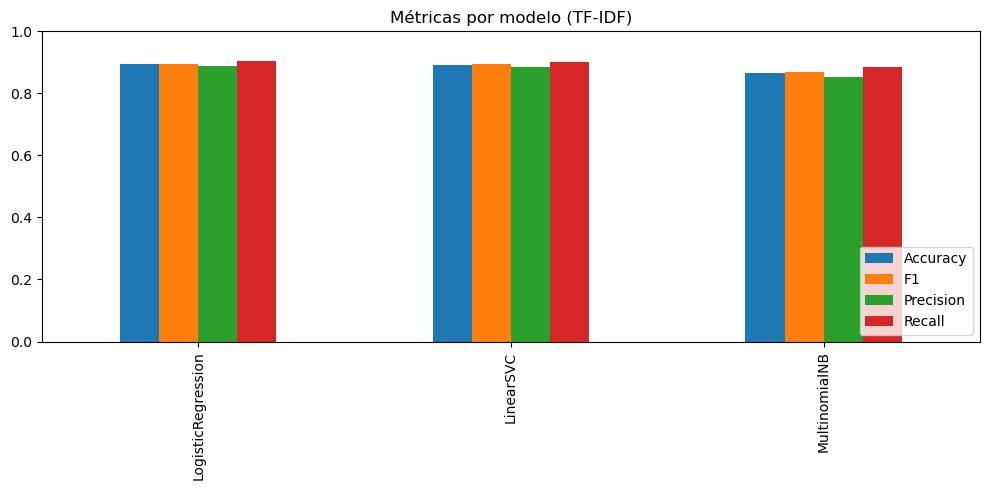

/tmp/ipykernel_41195/3268773688.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub["Modelo"] = pd.Categorical(sub["Modelo"], categories=order, ordered=True)
/tmp/ipykernel_41195/3268773688.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sub_pivot = sub.pivot_table(index="Modelo", columns="Métrica", values="Valor")


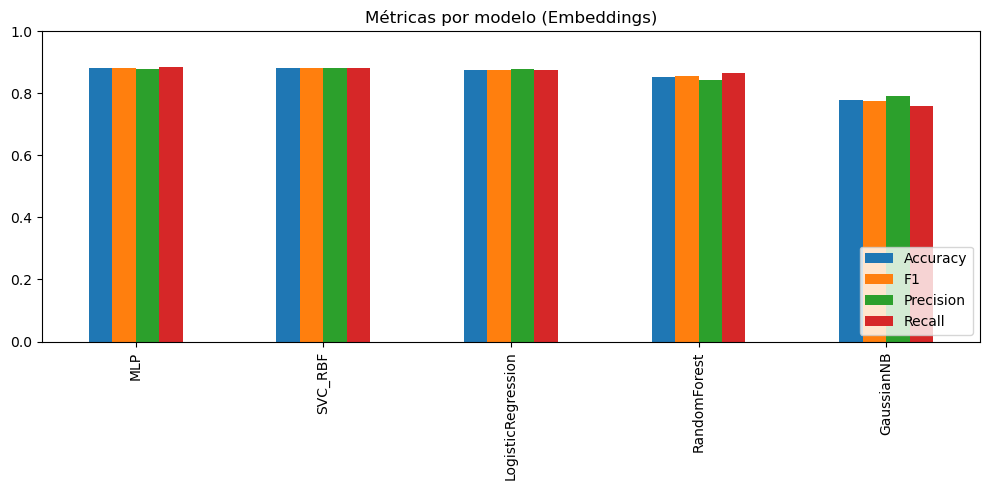

In [38]:
# ================================
# Visualización de métricas
# ================================
import matplotlib.pyplot as plt

plot_df = all_results.melt(
    id_vars=["Features","Modelo"],
    value_vars=["Accuracy","Precision","Recall","F1"],
    var_name="Métrica", value_name="Valor"
)

plt.figure(figsize=(10,5))
for feat in ["TF-IDF", "Embeddings"]:
    sub = plot_df[plot_df["Features"]==feat]
    order = (all_results[all_results["Features"]==feat]
             .sort_values("F1", ascending=False)["Modelo"].unique())
    sub["Modelo"] = pd.Categorical(sub["Modelo"], categories=order, ordered=True)
    sub = sub.sort_values(["Modelo","Métrica"])
    sub_pivot = sub.pivot_table(index="Modelo", columns="Métrica", values="Valor")
    sub_pivot.plot(kind="bar", figsize=(10,5), title=f"Métricas por modelo ({feat})")
    plt.ylim(0,1.0)
    plt.xlabel("")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


### Conclusiones comparativas: TF-IDF vs Word Embeddings

Los resultados obtenidos muestran un comportamiento coherente con la teoría sobre ambos enfoques de representación textual. En el caso de la representación TF-IDF, el mejor rendimiento global se alcanzó con la **Regresión Logística (F1 = 0.8955)**, seguida muy de cerca por el modelo **LinearSVC (F1 = 0.8937)**. Ambos clasificadores, de naturaleza lineal, aprovechan eficazmente la separabilidad léxica que ofrece el espacio de características TF-IDF. Su capacidad para ponderar términos frecuentes pero discriminativos permite capturar patrones de polaridad explícitos en el lenguaje, como la aparición de palabras claramente positivas o negativas (*excellent*, *bad*, *boring*, entre otras).

Por otro lado, en los modelos basados en **Word Embeddings**, el mejor desempeño correspondió a la **Red Neuronal Multicapa (MLP)** con un **F1 = 0.8825**, seguida por la **SVM con kernel RBF (F1 = 0.8810)**. Estos modelos no lineales logran aprovechar mejor la información semántica implícita en los vectores densos, permitiendo identificar similitudes de significado más allá de la coincidencia literal de las palabras y capturando con mayor profundidad el contexto de las oraciones.

Aunque el rendimiento promedio de los modelos con TF-IDF fue ligeramente superior (alrededor de un 1% de diferencia en F1), los embeddings demostraron una mayor robustez semántica y un mejor desempeño en frases complejas o contextualmente ambiguas. En términos generales, los resultados confirman que los **modelos lineales** (como la Regresión Logística y SVM) se comportan mejor sobre representaciones dispersas como TF-IDF, mientras que los **modelos no lineales** (como MLP y SVC con kernel RBF) se benefician de representaciones densas y continuas como las generadas por Word2Vec. Además, el modelo **Multinomial Naive Bayes**, pese a su simplicidad, mostró un rendimiento competitivo y una excelente relación entre eficiencia y precisión (F1 = 0.8688).

En conjunto, ambos enfoques se presentan como **complementarios**. TF-IDF destaca por su simplicidad, interpretabilidad y excelente rendimiento en problemas bien estructurados, mientras que Word2Vec aporta una representación semántica más rica que amplía la capacidad del modelo para comprender el significado contextual de las palabras. Por tanto, una combinación o integración de ambas representaciones —por ejemplo, mediante técnicas de *stacking* o mezcla ponderada de características— podría mejorar aún más la capacidad predictiva en tareas de análisis de sentimientos.
